# PerceptionMetrics Tutorial: LiDAR Segmentation Evaluation with RELLIS-3D

This notebook teaches you how to:
- Understand LiDAR point clouds
- Simulate semantic segmentation
- Compute IoU and mIoU
- Visualize results

Designed for contributors to PerceptionMetrics 


🔗 Connection to PerceptionMetrics

This tutorial demonstrates the core concepts behind the evaluation pipeline
used in the PerceptionMetrics library.

We implement IoU and mIoU manually for learning purposes.


## Optional: Using Real RELLIS-3D Dataset

This tutorial uses synthetic data for simplicity and to avoid heavy dependencies.

To extend this to real-world evaluation, you can use the RELLIS-3D dataset with the existing dataset loaders in PerceptionMetrics:

- `perceptionmetrics.datasets.rellis3d.Rellis3DLiDARSegmentationDataset`
- Predefined train/val/test splits
- Ontology and label mappings

Basic steps:
1. Download the RELLIS-3D dataset
2. Set dataset and split directories
3. Initialize the dataset class
4. Run evaluation using the same metric pipeline demonstrated above (IoU, mIoU, confusion matrix)

This keeps the tutorial beginner-friendly while allowing easy extension to real data.

In [ ]:
print(" If needed, install dependencies manually:")
print("pip install numpy torch matplotlib scipy")

 If needed, install dependencies manually:
pip install numpy torch matplotlib scipy


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import torch
import warnings

warnings.filterwarnings("ignore")

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

Using device: cpu


In [ ]:
RELLIS3D_CLASSES = {
    0: 'void', 1: 'dirt', 2: 'grass', 3: 'tree',
    4: 'pole', 5: 'water', 6: 'sky', 7: 'vehicle',
    8: 'object', 9: 'asphalt', 10: 'building',
    11: 'log', 12: 'person', 13: 'fence',
    14: 'bush', 15: 'concrete', 16: 'barrier',
    17: 'puddle', 18: 'mud'
}

print("Total classes:", len(RELLIS3D_CLASSES))

Total classes: 19


In [ ]:
def create_synthetic_scene(num_points=10000):
    np.random.seed(42)

    points = np.random.uniform(-50, 50, (num_points, 4)).astype(np.float32)

    gt = np.random.randint(0, 19, num_points)

    pred = gt.copy()

    # add noise (simulate imperfect model)
    noise_idx = np.random.choice(num_points, int(0.15 * num_points), replace=False)
    pred[noise_idx] = np.random.randint(0, 19, len(noise_idx))

    return points, gt, pred


points, gt_labels, pred_labels = create_synthetic_scene()

print("Points:", points.shape)
print("GT:", gt_labels.shape)
print("Pred:", pred_labels.shape)

Points: (10000, 4)
GT: (10000,)
Pred: (10000,)


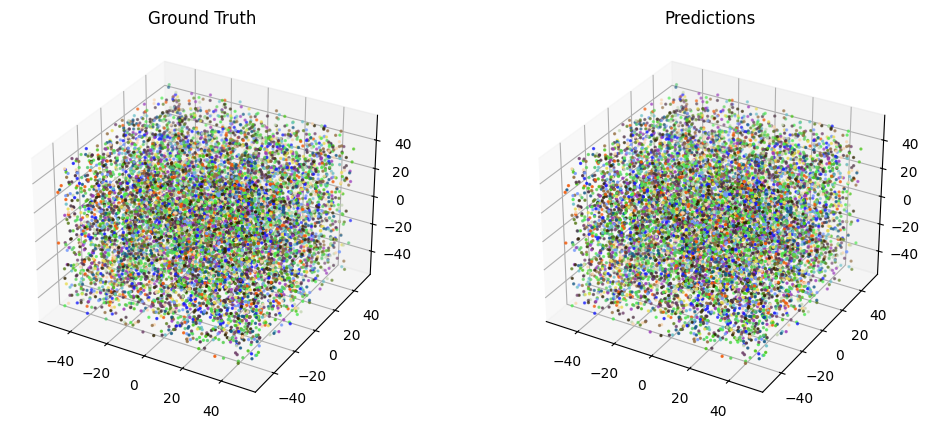

In [ ]:
colors = np.random.rand(19, 3)
cmap = ListedColormap(colors)

fig = plt.figure(figsize=(12, 5))

ax1 = fig.add_subplot(121, projection='3d')
ax1.scatter(points[:,0], points[:,1], points[:,2], c=gt_labels, cmap=cmap, s=2)
ax1.set_title("Ground Truth")

ax2 = fig.add_subplot(122, projection='3d')
ax2.scatter(points[:,0], points[:,1], points[:,2], c=pred_labels, cmap=cmap, s=2)
ax2.set_title("Predictions")

plt.show()

In [ ]:
class SegmentationMetrics:
    def __init__(self, num_classes):
        self.num_classes = num_classes
        self.confusion_matrix = np.zeros((num_classes, num_classes), dtype=np.int64)

    def update(self, pred, gt):
        for p, g in zip(pred, gt):
            if 0 <= g < self.num_classes and 0 <= p < self.num_classes:
                self.confusion_matrix[g, p] += 1

    def compute_iou(self):
        ious = []
        for i in range(self.num_classes):
            tp = self.confusion_matrix[i, i]
            fp = np.sum(self.confusion_matrix[:, i]) - tp
            fn = np.sum(self.confusion_matrix[i, :]) - tp

            denom = tp + fp + fn

            if denom > 0:
                iou = tp / denom
            else:
                iou = np.nan  # mark invalid classes

            ious.append(iou)

        return np.array(ious)

    def compute_miou(self):
        ious = self.compute_iou()

        # Only remove invalid classes (nan), NOT zero IoU
        valid_ious = ious[~np.isnan(ious)]

        return np.mean(valid_ious) if len(valid_ious) > 0 else 0.0

    def accuracy(self):
        total = np.sum(self.confusion_matrix)
        return np.trace(self.confusion_matrix) / total if total > 0 else 0.0

In [ ]:
metrics = SegmentationMetrics(19)

metrics.update(pred_labels, gt_labels)

ious = metrics.compute_iou()
miou = metrics.compute_miou()
acc = metrics.accuracy()

print("Accuracy:", acc)
print("mIoU:", miou)

Accuracy: 0.8594
mIoU: 0.7536432645091032


In [ ]:
print("\nPer-class IoU:\n")

for i, iou in enumerate(ious):
    print(f"{i} ({RELLIS3D_CLASSES[i]}): {iou:.4f}")


Per-class IoU:

0 (void): 0.7687
1 (dirt): 0.7615
2 (grass): 0.7668
3 (tree): 0.7826
4 (pole): 0.7608
5 (water): 0.7684
6 (sky): 0.7478
7 (vehicle): 0.7303
8 (object): 0.7593
9 (asphalt): 0.7782
10 (building): 0.7374
11 (log): 0.7479
12 (person): 0.7536
13 (fence): 0.7645
14 (bush): 0.7513
15 (concrete): 0.7311
16 (barrier): 0.7157
17 (puddle): 0.7712
18 (mud): 0.7222


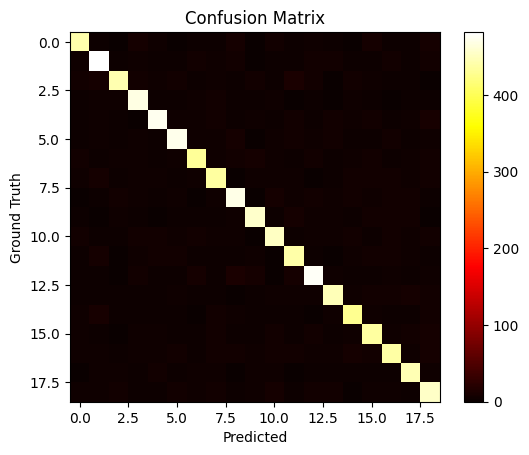

In [ ]:
plt.imshow(metrics.confusion_matrix, cmap='hot')
plt.title("Confusion Matrix")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("Ground Truth")
plt.show()


Contribution Note

This notebook helps new contributors understand:

- LiDAR data basics
- Segmentation evaluation
- IoU / mIoU logic

You can now contribute to PerceptionMetrics with clarity 
